**0. Импорт библиотек.**

In [1]:
import csv
import json
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from ipywidgets import interact_manual, Dropdown #выпадающый список

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import linregress

import plotly.express as px
import plotly.graph_objects as go

**1. Выгрузка `csv`-файла, который имеет информацию об `id` ученных, формат `sid` и годы (`bedin и end`).**

In [2]:
df = pd.read_csv('file.csv')

sid = 0
begin = 0
end = 0

options_sid = [100, 110, 120, 200, 210, 220]

@interact_manual(sid_options=Dropdown(options=options_sid, description="Тип профиля:"))
def _(sid_options):
    global sid
    sid = sid_options
    print(f"sid установлен: {sid}")

options_years = list(range(2000, 2026))

@interact_manual(begin_options=Dropdown(options=options_years, description="Год начала:"))
def _(begin_options):
    global begin
    begin = begin_options
    print(f"begin установлен: {begin}")

@interact_manual(end_options=Dropdown(options=options_years, description="Год конца:"))
def _(end_options):
    global end
    end = end_options
    print(f"end установлен: {end}")


interactive(children=(Dropdown(description='Тип профиля:', options=(100, 110, 120, 200, 210, 220), value=100),…

interactive(children=(Dropdown(description='Год начала:', options=(2000, 2001, 2002, 2003, 2004, 2005, 2006, 2…

interactive(children=(Dropdown(description='Год конца:', options=(2000, 2001, 2002, 2003, 2004, 2005, 2006, 20…

**2. Получение `json-файлов`: все факторы (темы), вектора каждого автора по каждому году, вектора каждого автора (за весь промежуток).**

*2.1. `Factors.json`:*

In [235]:
response = requests.get("http://193.232.208.28/api/v2.5/classifications/get_factors?clf_level=0")
data_level0 = response.json()

response = requests.get("http://193.232.208.28/api/v2.5/classifications/get_factors?clf_level=1")
data_level1 = response.json()

response = requests.get("http://193.232.208.28/api/v2.5/classifications/get_factors?clf_level=2")
data_level2 = response.json()

factors_by_level = {
    "0": {str(item["c_f_id"]): item["c_f_name"] for item in data_level0},
    "1": {str(item["c_f_id"]): item["c_f_name"] for item in data_level1},
    "2": {str(item["c_f_id"]): item["c_f_name"] for item in data_level2},
}

with open("factors.json", "w", encoding="utf-8") as f:
    json.dump(factors_by_level, f, indent=2, ensure_ascii=False)

*2.2. `Author_year_vectors.json`:*

In [282]:
data = {}
for author_id in df['id']:
    data[author_id] = {}
    for year in range(begin, end + 1):
        url_link = f"http://193.232.208.28/api/v2.5/authors/analysis/get_profile?id={author_id}&sid={sid}&begin_year={year}&end_year={year}"
        try:
            response = requests.get(url_link, timeout=10)
            data_profile = response.json()
            if "factors" in data_profile:
                data[author_id][year] = data_profile["factors"]
        except requests.exceptions.RequestException as e:
            print(f"Ошибка при author_id={author_id}, year={year}: {e}")
        
        # time.sleep(0.2)  # пауза, чтобы не заваливать сервер запросами

with open(f"author_year_vectors_sid={sid}.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

Ошибка при author_id=1, year=2000: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=1, year=2001: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=1, year=2002: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=1, year=2003: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=1, year=2004: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=1, year=2006: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=1, year=2007: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=2, year=2000: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=2, year=2001: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=2, year=2002: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=2, year=2003: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=2, year=2004: Expecting value: line 1 column 1 (char 0)
Ошибка при author_id=2, year=2005: Expecting value: line 1 column 1 (char 0)

*2.3. `Author_overall_vectors.json`:*

In [283]:
data_overall = {}
for author_id in df['id']:
    url_link = f"http://193.232.208.28/api/v2.5/authors/analysis/get_profile?id={author_id}&sid={sid}&begin_year={begin}&end_year={end}"
    try:
        response = requests.get(url_link, timeout=10)
        data_profile = response.json()
        if "factors" in data_profile:
            data_overall[author_id] = data_profile["factors"]
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при author_id={author_id}: {e}")

with open(f"author_overall_vectors_sid={sid}.json", "w", encoding="utf-8") as f:
    json.dump(data_overall, f, ensure_ascii=False, indent=2)

*2.4. `Author_fio.json`:*

In [69]:
data_fio = {}
for author_id in df['id']:
    url_link = f"http://193.232.208.28/api/v2.5/authors/search?id={author_id}"
    try:
        response = requests.get(url_link, timeout=15)
        data_profile = response.json()
        if data_profile:
            person = data_profile[0]
            data_fio[author_id] = {
                "last_name": person.get("last_name", ""),
                "first_name": person.get("first_name", ""),
                "sec_name": person.get("sec_name", "")
            }
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при author_id={author_id}: {e}")
    time.sleep(0.3)

with open("author_fio.json", "w", encoding="utf-8") as f:
    json.dump(data_fio, f, ensure_ascii=False, indent=2)

*2.5. Загрузка всех данных из `json` для дальнейшей работы:*

In [3]:
with open("factors.json", "r", encoding="utf-8") as f:
    factors_by_level = json.load(f)

with open(f"author_year_vectors_sid={sid}.json", "r", encoding="utf-8") as f:
    data_vectors = json.load(f)

with open(f"author_overall_vectors_sid={sid}.json", "r", encoding="utf-8") as f:
    data_overall = json.load(f)

with open("author_fio.json", "r", encoding="utf-8") as f:
    data_fio = json.load(f)

print(f"Авторов с погодовыми данными: {len(data_vectors)}")
print(f"Авторов с обобщёнными данными: {len(data_overall)}")
print(f"ФИО авторов: {len(data_fio)}")

Авторов с погодовыми данными: 53
Авторов с обобщёнными данными: 53
ФИО авторов: 53


**3. Аналитика.**

*3.1. Одиночный анализ.*

* 3.1.1. Профиль автора в течение промежутка времени, а не по годам (ФИО, топ тем и визуализация):

In [4]:
def show_author_profile(author, data_overall, factors_by_level, data_fio):
    person = data_fio.get(str(author))
    print(f"ФИО автора c id = {author}: {person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}")
    data_person_sort = dict(sorted(data_overall.get(str(author)).items(), key=lambda item: -item[1]))
    factors_map = factors_by_level[str(sid)[1]]

    for i in data_person_sort:
        data_person_sort[i] = data_person_sort.get(str(i)) * 100
        print(f"{factors_by_level[str(sid)[1]][i]}: {data_person_sort[i]} %")

def plot_author_profile(author, data_overall, factors_by_level, data_fio):
    person = data_fio.get(str(author))
    fio = f"{person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}"
    
    data_person_sort = dict(sorted(data_overall.get(str(author)).items(), key=lambda item: -item[1]))
    factors_map = factors_by_level[str(sid)[1]]
    
    items = list(data_person_sort.items())[:len(factors_map)]
    
    names = [factors_map.get(topic_id, topic_id) for topic_id, _ in items]
    percents = [weight * 100 for _, weight in items]
    
    plt.figure(figsize=(30, 30))
    plt.barh(names[::-1], percents[::-1], color="#4C72B0", height=0.5)
    
    for i, value in enumerate(percents[::-1]):
        plt.text(value + 0.5, i, f"{value:.1f}%", va="center")
    
    plt.xlabel("Доля, %")
    plt.title(f"Тематический профиль: {fio}")
    plt.tight_layout()
    plt.show()

* 3.1.2. Энтропия автора (широта охвата автора за весь период).

Энтропия - это способ сжать сложную многомерную картину интересов человека в одно сравнимое число, которое напрямую отвечает на конкретный, содержательный вопрос ("специализирован или разбросан") и становится основой для дальнейших сравнений между людьми и во времени — то есть это не самоцель, а строительный блок для более крупной аналитики школы.

In [5]:
def entropy(author, data, data_fio):
    person = data_fio.get(str(author))
    fio = f"{person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}"

    data_person = dict(data.get(str(author)))
    H = 0
    for i in data_person:
        if data_person[i] != 0:
            H -= data_person[i] * math.log2(data_person[i])
    H_norm = H / math.log2(len(data_person))
    print("Чем ближе к 100% — тем более разносторонний человек (универсал), а не специалист. Чем ближе к 0% — тем более узкий специалист, сфокусированный на одной-двух темах.")
    print(f"{fio} имеет энтропию = {H}")
    print(f"Нормированная энтропия = {H_norm} или = {round(H_norm, 3) * 100}%")
    return H, H_norm

* 3.1.3. Топ-тема каждого года.

In [6]:
def top_year(author, data_vectors, factors_by_level):
    print("\nТоп тем каждого года:")
    factors_map = factors_by_level[str(sid)[1]]

    data = dict(data_vectors.get(str(author)))
    data_top = {}
    for year, factor in data.items():
        max_factor = max(factor.items(), key=lambda item: item[1])
        data_top[year] = max_factor
        topic_id, weight = max_factor
        topic_name = factors_map.get(topic_id, topic_id)
        print(f"{year}: {topic_name} ({weight*100:.1f}%)")

def plot_top_year(author, data_vectors, factors_by_level):
    factors_map = factors_by_level[str(sid)[1]]
    data = dict(data_vectors.get(str(author)))
    
    years = []
    topic_names = []
    for year, factor in data.items():
        max_factor = max(factor.items(), key=lambda item: item[1])
        topic_id, weight = max_factor
        topic_name = factors_map.get(topic_id, topic_id)
        years.append(int(year))
        topic_names.append(topic_name)
    
    # присваиваем каждой уникальной теме свой цвет
    unique_topics = list(set(topic_names))
    colors = plt.cm.tab20(range(len(unique_topics)))
    topic_to_color = {topic: colors[i] for i, topic in enumerate(unique_topics)}
    
    plt.figure(figsize=(12, 2))
    for i in range(len(years)):
        plt.barh(0, 1, left=i, color=topic_to_color[topic_names[i]], edgecolor="white")
    
    plt.yticks([])
    plt.xticks(range(len(years)), years, rotation=90)
    plt.title("Топ-тема по годам")
    
    # легенда
    handles = [plt.Rectangle((0,0),1,1, color=topic_to_color[t]) for t in unique_topics]
    plt.legend(handles, unique_topics, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

* 3.1.4. Энтропия автора по каждому году. 

Показывает, кем был автор в каждый свой год: специалистом в одной теме или универсалом. Стоит иметь в виду при интерпретации: годы с низким числом публикаций дают "шумную", не очень репрезентативную энтропию.

In [7]:
def entropy_by_year(author, data_vectors):
    print("\nДинамика энтропии по каждому году:")
    data_person = dict(data_vectors.get(str(author)))

    for year in data_person:
        H = 0
        for i in data_person[year]:
            if data_person[year][i] != 0:
                H -= data_person[year][i] * math.log2(data_person[year][i])
        H_norm = H / math.log2(len(data_person[year]))
        print(f"{year}: Энтропия = {H}; Нормированная энтропия = {H_norm} ({round(H_norm, 3) * 100}%)")

def plot_entropy_by_year(author, data_vectors, data_fio):
    data_person = dict(data_vectors.get(str(author)))

    years = []
    norms = []
    for year in data_person:
        H = 0
        for i in data_person[year]:
            if data_person[year][i] != 0:
                H -= data_person[year][i] * math.log2(data_person[year][i])
        H_norm = H / math.log2(len(data_person[year]))
        years.append(int(year))
        norms.append(H_norm * 100)

    plt.figure(figsize=(10, 5))
    plt.plot(years, norms, marker='o', color="#4C72B0")
    plt.xlabel("Год")
    plt.ylabel("Нормированная энтропия, %")
    plt.title("Динамика энтропии по годам")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

* 3.1.5. Траектория автора в пространстве тем.

Каждая точка = один год. Точки соединены линией в хронологическом порядке (некий "путь"). Если точки для соседних лет расположены близко друг к другу - тематика менялась плавно; если далеко - резкая смена направления.

In [8]:
def plot_author_trajectory(author, data_vectors, factors_by_level, data_fio):
    person = data_fio.get(str(author))
    fio = f"{person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}"
    
    data_person = dict(data_vectors.get(str(author)))
    years = sorted(data_person.keys(), key=int)
    
    # берём список всех id тем (одинаковый порядок для всех лет)
    all_topic_ids = list(factors_by_level[str(sid)[1]].keys())
    
    # строим матрицу: строки - года, столбцы - темы
    matrix = []
    for year in years:
        vec = data_person[year]
        row = [vec.get(topic_id, 0) for topic_id in all_topic_ids]
        matrix.append(row)
    matrix = np.array(matrix)
    
    # PCA до 2 компонент
    pca = PCA(n_components=2)
    coords = pca.fit_transform(matrix)
    
    # рисуем
    plt.figure(figsize=(8, 6))
    plt.plot(coords[:, 0], coords[:, 1], '-', color="gray", alpha=0.5, zorder=1)
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=[int(y) for y in years], cmap="viridis", s=100, zorder=2)
    
    for i, year in enumerate(years):
        plt.annotate(year, (coords[i, 0], coords[i, 1]), fontsize=8, ha="center", va="bottom")
    
    plt.colorbar(scatter, label="Год")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)")
    plt.title(f"Траектория в пространстве тем: {fio}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

*Профиль автора:*

In [9]:
def build_fio_string(author_id, data_fio):
    person = data_fio.get(str(author_id))
    if not person:
        return f"Автор #{author_id}"
    return f"{person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}".strip()

options = {
    build_fio_string(aid, data_fio) + f" (id={aid})": str(aid) for aid in data_fio.keys()
}

@interact_manual(author=Dropdown(options=options, description="Автор:"))
def _(author):
    show_author_profile(author, data_overall, factors_by_level, data_fio)
    plot_author_profile(author, data_overall, factors_by_level, data_fio)
    entropy(author, data_overall, data_fio)
    top_year(author, data_vectors, factors_by_level)
    plot_top_year(author, data_vectors, factors_by_level)
    entropy_by_year(author, data_vectors)
    plot_entropy_by_year(author, data_vectors, data_fio)
    plot_author_trajectory(author, data_vectors, factors_by_level, data_fio)

interactive(children=(Dropdown(description='Автор:', options={'Нижегородцев Роберт Михайлович (id=1)': '1', 'П…

*3.2. Сравнение авторов между собой.*

* 3.2.1. Матрицы близости всех авторов.

In [10]:
def proximity_matrix_overall(data_overall, factors_by_level):
    author_id = [i for i in data_overall]

    all_topic_ids = list(factors_by_level[str(sid)[1]].keys())
    
    matrix = []
    for i in author_id:
        vector = data_overall[i]
        row = [vector.get(topic_id, 0) for topic_id in all_topic_ids]
        matrix.append(row)
    matrix = np.array(matrix)

    similarity_matrix = cosine_similarity(matrix)

    return similarity_matrix, author_id

def plot_similarity_heatmap(similarity_matrix, author_ids, data_fio):
    labels = [build_fio_string(aid, data_fio) for aid in author_ids]
    
    plt.figure(figsize=(16, 16))
    sns.heatmap(similarity_matrix, xticklabels=labels, yticklabels=labels, cmap="viridis", 
                square=True, cbar_kws={"label": "Косинусное сходство"})
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(fontsize=7)
    plt.title("Матрица тематической близости авторов школы")
    plt.tight_layout()
    plt.show()

* 3.2.2. Близость каждого автора к выбранному автору (к кому-то одному).

In [11]:
def proximity_matrix_author(similarity_matrix, author, author_ids, data_fio):
    index = author_ids.index(str(author))

    list_proximity_author = similarity_matrix[index]

    dict_proximity = {}
    for i in range(len(author_ids)):
        if i != index:
            person = data_fio.get(str(author_ids[i]))
            fio = f"{person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}"
            dict_proximity[fio] = float(list_proximity_author[i])
    sorted_dict_proximity = sorted(dict_proximity.items(), key=lambda item: -item[1])
    return sorted_dict_proximity

def plot_proximity_author(similarity_matrix, author, author_ids, data_fio):
    index = author_ids.index(str(author))
    list_proximity_author = similarity_matrix[index]

    dict_proximity = {}
    for i in range(len(author_ids)):
        if i != index:
            person = data_fio.get(str(author_ids[i]))
            fio = f"{person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}"
            dict_proximity[fio] = float(list_proximity_author[i])
    
    sorted_items = sorted(dict_proximity.items(), key=lambda item: -item[1])
    names = [item[0] for item in sorted_items]
    scores = [item[1] for item in sorted_items]
    
    target_fio = build_fio_string(author, data_fio)
    
    fig, ax = plt.subplots(figsize=(9, max(6, len(names) * 0.3)))
    bars = ax.barh(names[::-1], scores[::-1], color="#4C72B0")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)
    ax.set_xlabel("Косинусное сходство")
    ax.set_xlim(0, 1.05)  # чуть больше 1, чтобы подписи не обрезались справа
    ax.set_title(f"Близость всех авторов к: {target_fio}")
    plt.tight_layout()
    plt.show()

* 3.2.3. Кластеризация.

Изначальную матрицу близости переформировывает.

In [12]:
def plot_similarity_clustermap(similarity_matrix, author_ids, data_fio):
    labels = [build_fio_string(aid, data_fio) for aid in author_ids]
    
    # clustermap сам проводит иерархическую кластеризацию и переставляет строки/столбцы
    g = sns.clustermap(similarity_matrix, xticklabels=labels, yticklabels=labels, cmap="viridis",
                        figsize=(14, 14), cbar_kws={"label": "Косинусное сходство"})
    
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=7)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
    g.fig.suptitle("Матрица близости (переупорядочено по кластерам)", y=1.02)
    
    plt.show()
    
    # достаём новый порядок, чтобы не терять контекст
    new_order = g.dendrogram_row.reordered_ind
    new_order_ids = [author_ids[i] for i in new_order]
    new_order_fio = [labels[i] for i in new_order]
    
    return new_order_ids, new_order_fio

def cluster_authors(similarity_matrix, author_ids, data_fio, n_clusters=12, save_path="clusters_output.txt"):
    distance_matrix = 1 - similarity_matrix
    
    clustering = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
    labels = clustering.fit_predict(distance_matrix)
    
    clusters = {}
    for author_id, label in zip(author_ids, labels):
        fio = build_fio_string(author_id, data_fio)
        clusters.setdefault(label, []).append(fio)
    
    with open(save_path, "w", encoding="utf-8") as f:
        for cluster_id in sorted(clusters.keys()):
            members = clusters[cluster_id]
            header = f"Кластер {cluster_id + 1} ({len(members)} человек):"
            print(header)
            f.write(header + "\n")
            for fio in members:
                line = f"  - {fio}"
                print(line)
                f.write(line + "\n")
            print()
            f.write("\n")
    
    print(f"Результат сохранён в файл: {save_path}")
    return clusters

* 3.2.4. Энтропия всех авторов.

In [13]:
def entropy_all_authors(data_overall, data_fio, top_n=None):
    results = {}
    for author_id in data_overall.keys():
        person = data_fio.get(str(author_id))
        if not person:
            continue
        fio = f"{person.get('last_name', '')} {person.get('first_name', '')} {person.get('sec_name', '')}"
        
        data_person = dict(data_overall.get(str(author_id)))
        H = 0
        for i in data_person:
            if data_person[i] != 0:
                H -= data_person[i] * math.log2(data_person[i])
        H_norm = H / math.log2(len(data_person))
        
        results[fio] = (H, H_norm)
    
    sorted_results = sorted(results.items(), key=lambda item: -item[1][1])
    
    if top_n:
        sorted_results = sorted_results[:top_n]
    
    print("Рейтинг по разносторонности (от самых широких к самым узким):\n")
    for fio, (H, H_norm) in sorted_results:
        print(f"  {fio}: {H_norm*100:.1f}%")
    
    return sorted_results

def plot_entropy_ranking(sorted_results):
    names = [item[0] for item in sorted_results]
    values = [item[1][1] * 100 for item in sorted_results]
    
    fig, ax = plt.subplots(figsize=(9, max(6, len(names) * 0.3)))
    bars = ax.barh(names[::-1], values[::-1], color="#4C72B0")
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=7)
    ax.set_xlabel("Нормированная энтропия, %")
    ax.set_xlim(0, 105)
    ax.set_title("Рейтинг разносторонности авторов школы")
    plt.tight_layout()
    plt.show()

*Профили сравнения:*

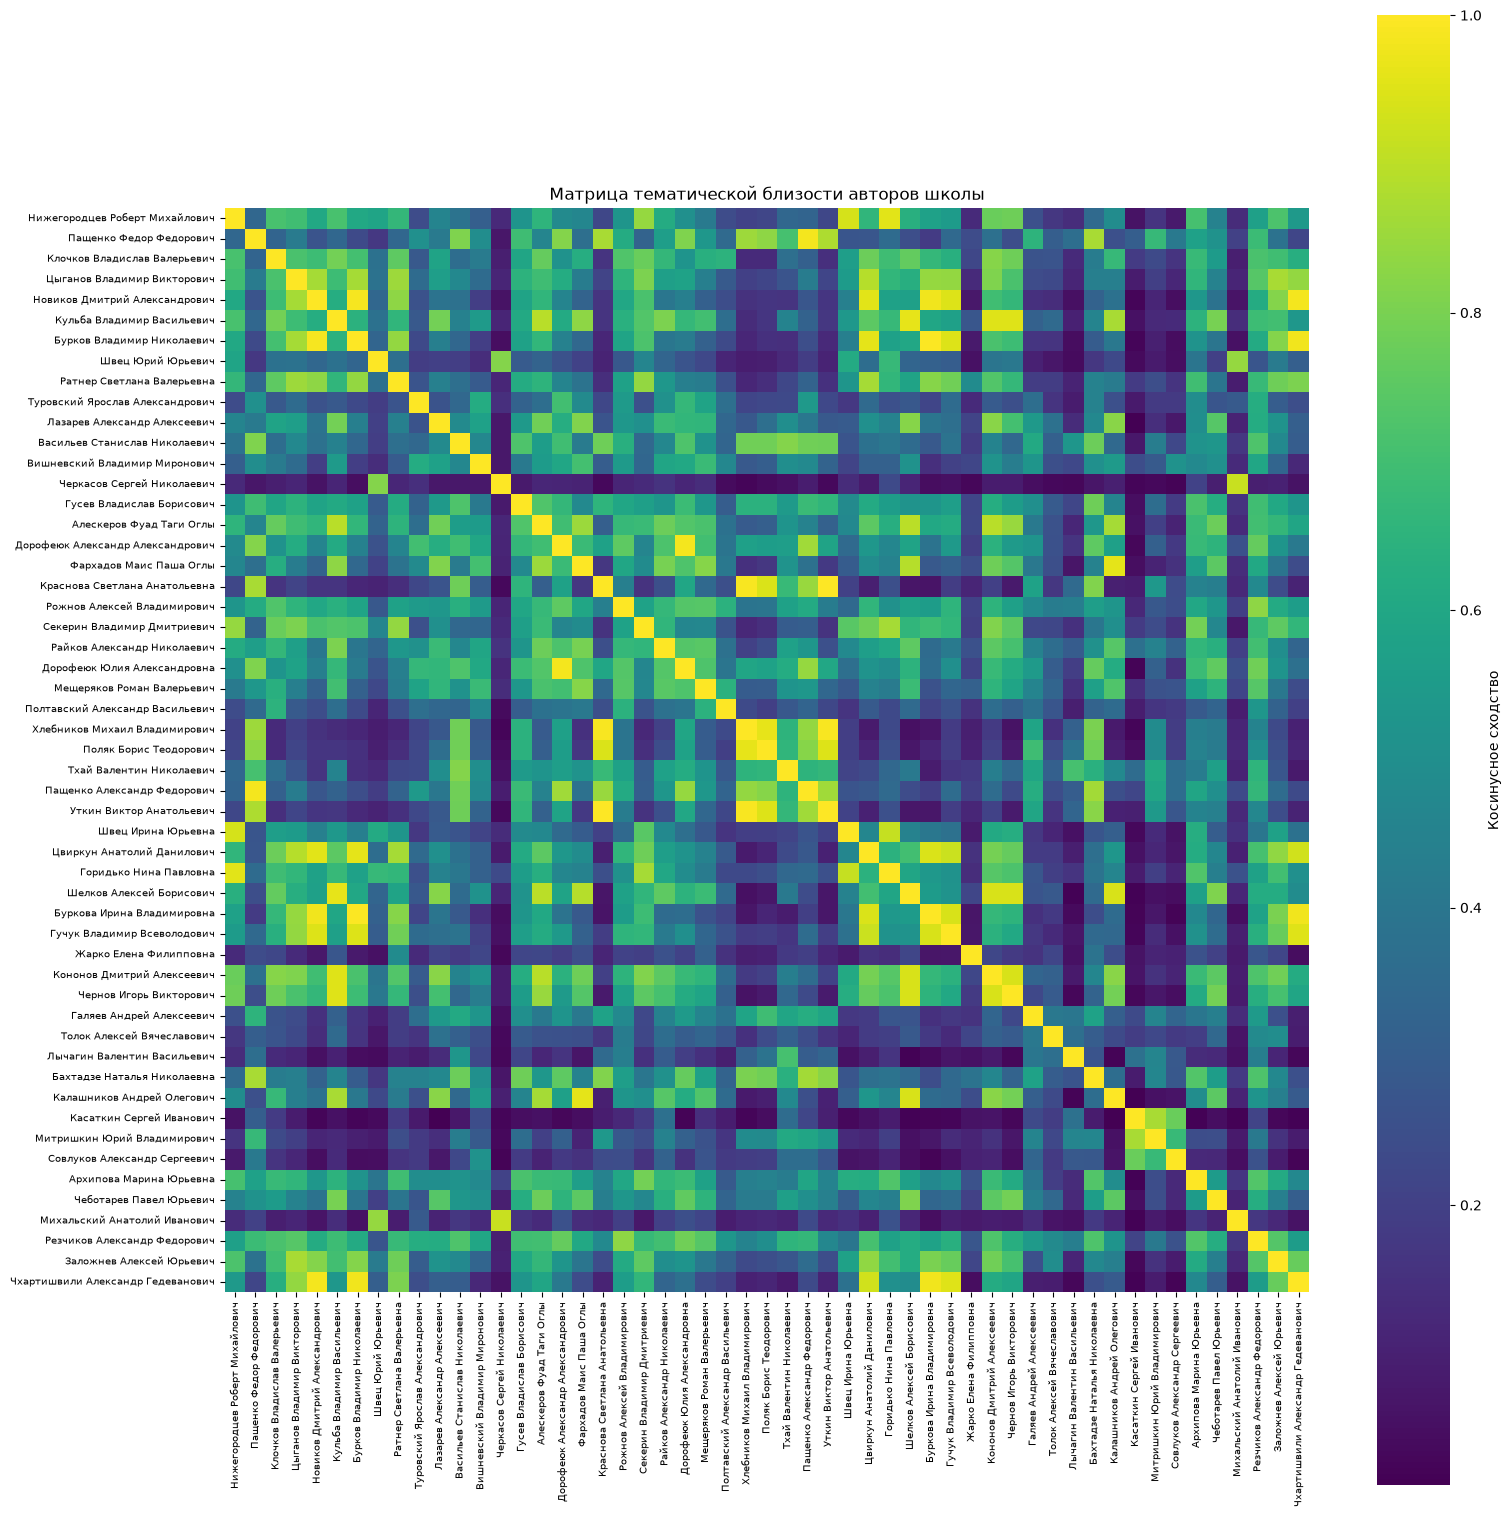

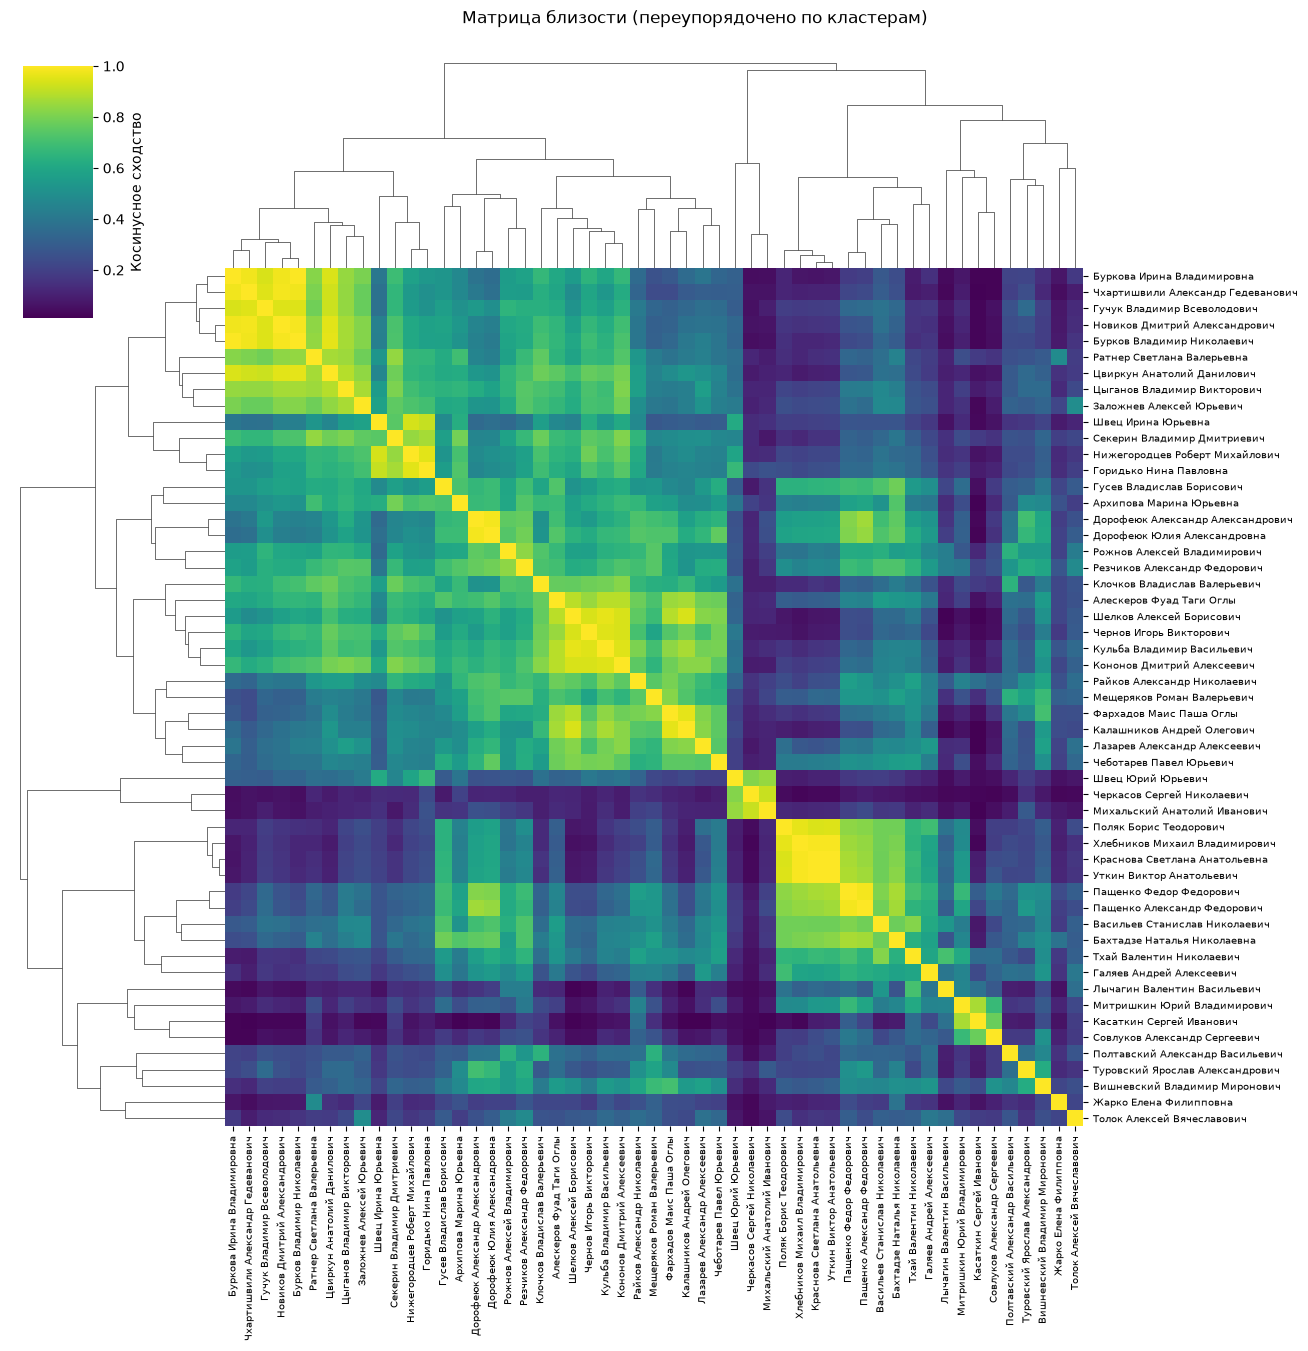

Кластер 1 (10 человек):
  - Пащенко Федор Федорович
  - Васильев Станислав Николаевич
  - Краснова Светлана Анатольевна
  - Хлебников Михаил Владимирович
  - Поляк Борис Теодорович
  - Тхай Валентин Николаевич
  - Пащенко Александр Федорович
  - Уткин Виктор Анатольевич
  - Галяев Андрей Алексеевич
  - Бахтадзе Наталья Николаевна

Кластер 2 (16 человек):
  - Клочков Владислав Валерьевич
  - Кульба Владимир Васильевич
  - Лазарев Александр Алексеевич
  - Алескеров Фуад Таги Оглы
  - Дорофеюк Александр Александрович
  - Фархадов Маис Паша Оглы
  - Рожнов Алексей Владимирович
  - Райков Александр Николаевич
  - Дорофеюк Юлия Александровна
  - Мещеряков Роман Валерьевич
  - Шелков Алексей Борисович
  - Кононов Дмитрий Алексеевич
  - Чернов Игорь Викторович
  - Калашников Андрей Олегович
  - Чеботарев Павел Юрьевич
  - Резчиков Александр Федорович

Кластер 3 (2 человек):
  - Туровский Ярослав Александрович
  - Вишневский Владимир Миронович

Кластер 4 (1 человек):
  - Лычагин Валентин Василь

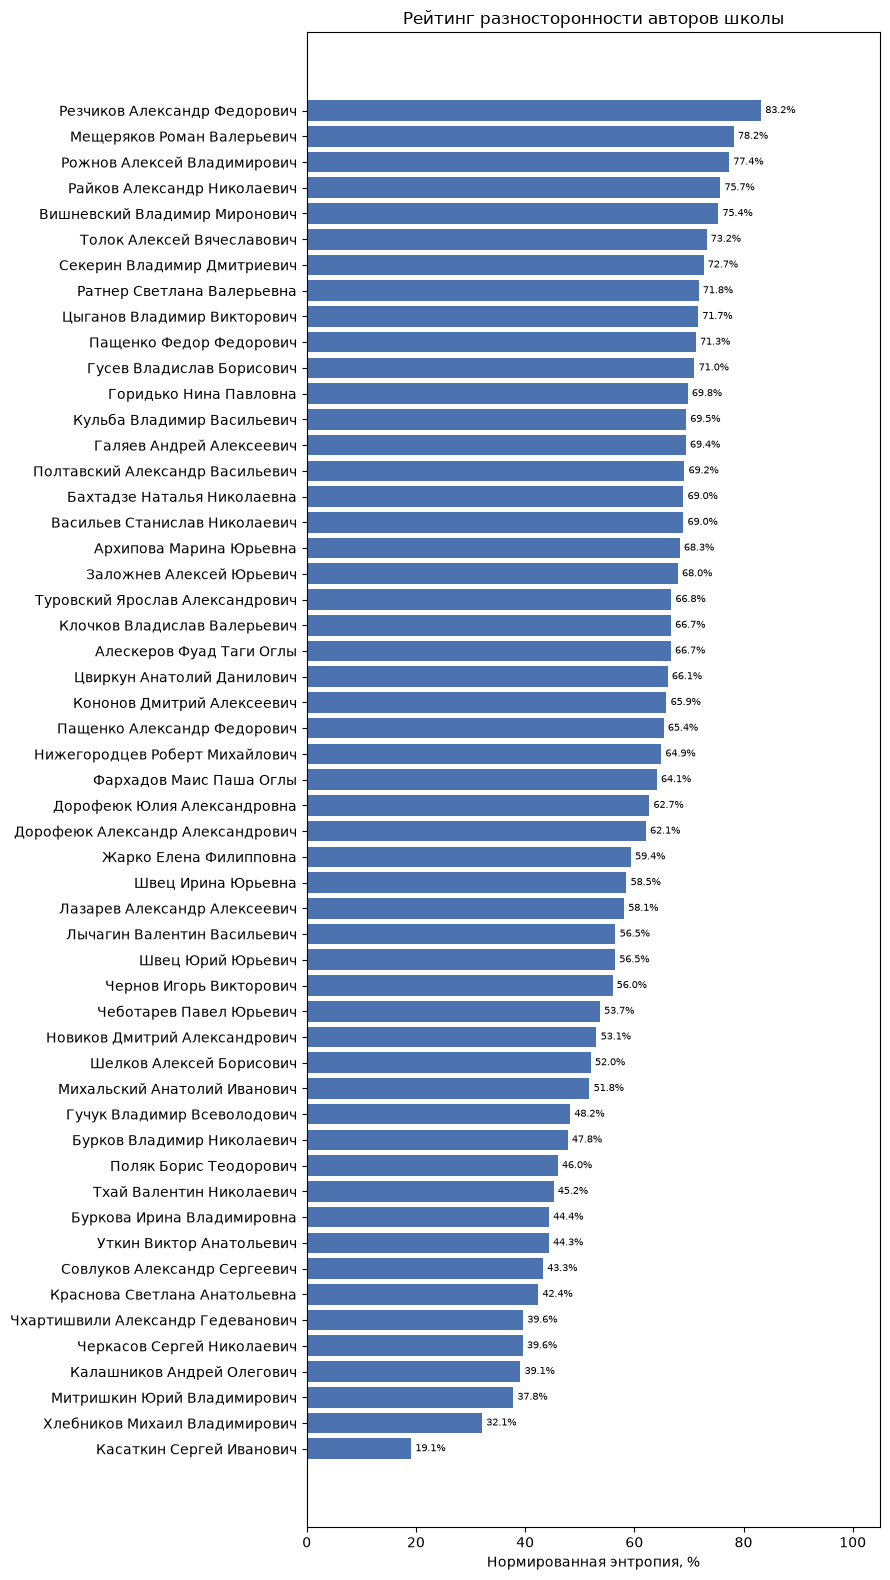

ТЕМАТИЧЕСКАЯ БЛИЗОСТЬ АВТОРОВ К ВЫБРАННОМУ АВТОРУ:


interactive(children=(Dropdown(description='Автор:', options={'Нижегородцев Роберт Михайлович (id=1)': '1', 'П…

In [ ]:
similarity_matrix, author_ids = proximity_matrix_overall(data_overall, factors_by_level)
plot_similarity_heatmap(similarity_matrix, author_ids, data_fio)

new_order_ids, new_order_fio = plot_similarity_clustermap(similarity_matrix, author_ids, data_fio)
clusters = cluster_authors(similarity_matrix, author_ids, data_fio, n_clusters=12, save_path="clusters_n8.txt")

sorted_results = entropy_all_authors(data_overall, data_fio)
plot_entropy_ranking(sorted_results)

print("ТЕМАТИЧЕСКАЯ БЛИЗОСТЬ АВТОРОВ К ВЫБРАННОМУ АВТОРУ:")
@interact_manual(author=Dropdown(options=options, description="Автор:"))
def _(author):
    result = proximity_matrix_author(similarity_matrix, author, author_ids, data_fio)
    print(f"Ближайшие по тематике авторы:\n")
    for fio, score in result[:10]:
        print(f"  {fio}: {score:.3f}")
    plot_proximity_author(similarity_matrix, author, author_ids, data_fio)

*3.3. Динамика тем/авторов по годам.*

3.3.1. Агрегация в вектор школы за каждый год.

In [15]:
def school_vector_for_year(year, data_vectors):
    year = str(year)
    
    result = {}
    n_authors = 0
    
    for author_id, yearly_data in data_vectors.items():
        if year in yearly_data:
            vector = yearly_data[year]
            for topic_id, weight in vector.items():
                result[topic_id] = result.get(topic_id, 0) + weight
            n_authors += 1
    
    if n_authors == 0:
        return {}, 0
    
    school_vector = {topic_id: total / n_authors for topic_id, total in result.items()}
    
    return school_vector, n_authors


def school_vectors_all_years(data_vectors, factors_by_level, start_year=2000, end_year=2025, top_n=3):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    all_years_data = {}
    
    for year in range(start_year, end_year + 1):
        vector, n_authors = school_vector_for_year(year, data_vectors)
        if n_authors > 0:
            all_years_data[year] = {"vector": vector, "n_authors": n_authors}
            
            top_topics = sorted(vector.items(), key=lambda x: -x[1])[:top_n]
            top_str = ", ".join(f"{factors_map.get(tid, tid)} ({w*100:.1f}%)" for tid, w in top_topics)
            print(f"{year} ({n_authors} авт.): {top_str}")
    
    return all_years_data


def plot_school_topic_dynamics(school_by_year, factors_by_level, top_n):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    years = sorted(school_by_year.keys())
    
    avg_weights = {}
    for year in years:
        vector = school_by_year[year]["vector"]
        for topic_id, weight in vector.items():
            avg_weights[topic_id] = avg_weights.get(topic_id, 0) + weight
    for topic_id in avg_weights:
        avg_weights[topic_id] /= len(years)
    
    top_topics = sorted(avg_weights.items(), key=lambda x: -x[1])[:top_n]
    top_topic_ids = [t[0] for t in top_topics]
    
    # --- график топ тем за всё время (вместо таблицы) ---
    names = [factors_map.get(tid, tid) for tid, _ in top_topics]
    values = [w * 100 for _, w in top_topics]
    
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.4)))
    bars = ax.barh(names[::-1], values[::-1], color="#4C72B0")
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_xlabel("Средняя доля, %")
    ax.set_title(f"Топ-{top_n} тем школы за весь период")
    plt.tight_layout()
    plt.show()
    
    # --- график динамики по годам ---
    plt.figure(figsize=(19, 12))
    for topic_id in top_topic_ids:
        values_year = [school_by_year[year]["vector"].get(topic_id, 0) * 100 for year in years]
        topic_name = factors_map.get(topic_id, topic_id)
        plt.plot(years, values_year, marker='o', markersize=3, label=topic_name)
    
    plt.xlabel("Год")
    plt.ylabel("Доля в векторе школы, %")
    plt.title(f"Динамика топ-{top_n} тем школы по годам")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

* 3.3.2. Тренд каждой темы (линейная регрессия).

In [16]:
def compute_topic_trends(school_by_year, factors_by_level):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    years = sorted(school_by_year.keys())
    
    # собираем все уникальные id тем, которые встречались хотя бы раз
    all_topic_ids = set()
    for year in years:
        all_topic_ids.update(school_by_year[year]["vector"].keys())
    
    trends = {}
    for topic_id in all_topic_ids:
        values = [school_by_year[year]["vector"].get(topic_id, 0) for year in years]
        
        result = linregress(years, values)
        trends[topic_id] = {
            "slope": result.slope,
            "intercept": result.intercept,
            "r_value": result.rvalue,
            "p_value": result.pvalue
        }
    
    return trends


def print_topic_trends(trends, factors_by_level, top_n):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    
    sorted_trends = sorted(trends.items(), key=lambda x: -x[1]["slope"])
    
    print(f"Топ-{top_n} РАСТУЩИХ тем:\n")
    for topic_id, data in sorted_trends[:top_n]:
        name = factors_map.get(topic_id, topic_id)
        print(f"  {name}: наклон = {data['slope']*100:.3f} п.п./год (p={data['p_value']:.3f})")
    
    print(f"\nТоп-{top_n} ПАДАЮЩИХ тем:\n")
    for topic_id, data in sorted_trends[-top_n:][::-1]:
        name = factors_map.get(topic_id, topic_id)
        print(f"  {name}: наклон = {data['slope']*100:.3f} п.п./год (p={data['p_value']:.3f})")
    
    return sorted_trends

def plot_topic_trends(trends, factors_by_level, top_n=None, significance_threshold=0.05):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    
    sorted_trends = sorted(trends.items(), key=lambda x: -x[1]["slope"])
    
    if top_n:
        # берём top_n растущих и top_n падающих
        sorted_trends = sorted_trends[:top_n] + sorted_trends[-top_n:]
    
    names = [factors_map.get(tid, tid) for tid, _ in sorted_trends]
    slopes = [data["slope"] * 100 for _, data in sorted_trends]  # в п.п./год
    p_values = [data["p_value"] for _, data in sorted_trends]
    
    # цвет по значимости: значимые - синий/красный, незначимые - серый
    colors = []
    for slope, p in zip(slopes, p_values):
        if p < significance_threshold:
            colors.append("#2E8B57" if slope > 0 else "#B22222")  # зелёный рост / красный падение
        else:
            colors.append("#B0B0B0")  # серый - незначимо
    
    fig, ax = plt.subplots(figsize=(9, max(6, len(names) * 0.3)))
    bars = ax.barh(names[::-1], slopes[::-1], color=colors[::-1])
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Наклон тренда, п.п./год")
    ax.set_title("Тренды тем школы (зелёный/красный — значимо при p<0.05, серый — незначимо)")
    plt.tight_layout()
    plt.show()

* 3.3.3. Ядро vs периферия школы.

Узнать темы, которые есть у большинства

In [17]:
def compute_topic_reach(data_overall, factors_by_level, threshold=0.05):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    
    topic_author_count = {}
    
    for author_id, vector in data_overall.items():
        for topic_id, weight in vector.items():
            if weight >= threshold:
                topic_author_count[topic_id] = topic_author_count.get(topic_id, 0) + 1
    
    # добавляем темы, у которых вообще нет авторов выше порога (0 человек)
    for topic_id in factors_map.keys():
        if topic_id not in topic_author_count:
            topic_author_count[topic_id] = 0
    
    return topic_author_count


def plot_topic_reach(topic_author_count, factors_by_level, threshold, top_n=None):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    
    sorted_reach = sorted(topic_author_count.items(), key=lambda x: -x[1])
    
    if top_n:
        sorted_reach = sorted_reach[:top_n]
    
    names = [factors_map.get(tid, tid) for tid, _ in sorted_reach]
    counts = [count for _, count in sorted_reach]
    
    fig, ax = plt.subplots(figsize=(9, max(6, len(names) * 0.3)))
    bars = ax.barh(names[::-1], counts[::-1], color="#4C72B0")
    ax.bar_label(bars, padding=3, fontsize=7)
    ax.set_xlabel("Число авторов, у кого тема значима")
    ax.set_title(f"Ядро vs периферия школы (порог веса: {threshold*100:.0f}%)")
    plt.tight_layout()
    plt.show()

* 3.3.4. Активность школы по годам.

In [18]:
def plot_school_activity(school_by_year):
    years = sorted(school_by_year.keys())
    n_authors = [school_by_year[year]["n_authors"] for year in years]
    
    plt.figure(figsize=(10, 5))
    plt.plot(years, n_authors, marker='o', color="#4C72B0")
    plt.xlabel("Год")
    plt.ylabel("Число авторов с публикациями")
    plt.title("Активность школы по годам")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

*Профиль авторов:*

2001 (7 авт.): Информационные технологии в управлении (28.6%), Управление в организационных системах (15.2%), Теория графов (14.3%)
2002 (10 авт.): Управление в организационных системах (45.0%), Социально-экономические системы (30.0%), Автоматическое управление (15.8%)
2003 (10 авт.): Управление в организационных системах (36.5%), Информационные технологии в управлении (22.4%), Автоматическое управление (14.0%)
2004 (8 авт.): Управление в организационных системах (67.9%), Социально-экономические системы (15.6%), Информационные технологии в управлении (6.4%)
2005 (33 авт.): Управление в организационных системах (18.6%), Смежные методы и технологии (14.8%), Автоматическое управление (11.9%)
2006 (37 авт.): Смежные методы и технологии (22.8%), Управление в организационных системах (16.8%), Автоматическое управление (16.6%)
2007 (41 авт.): Управление в организационных системах (20.5%), Автоматическое управление (16.7%), Смежные методы и технологии (12.4%)
2008 (45 авт.): Управление в орган

interactive(children=(Dropdown(description='Кол-во в топе тем:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1…

interactive(children=(Dropdown(description='Кол-во в топе тем:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1…

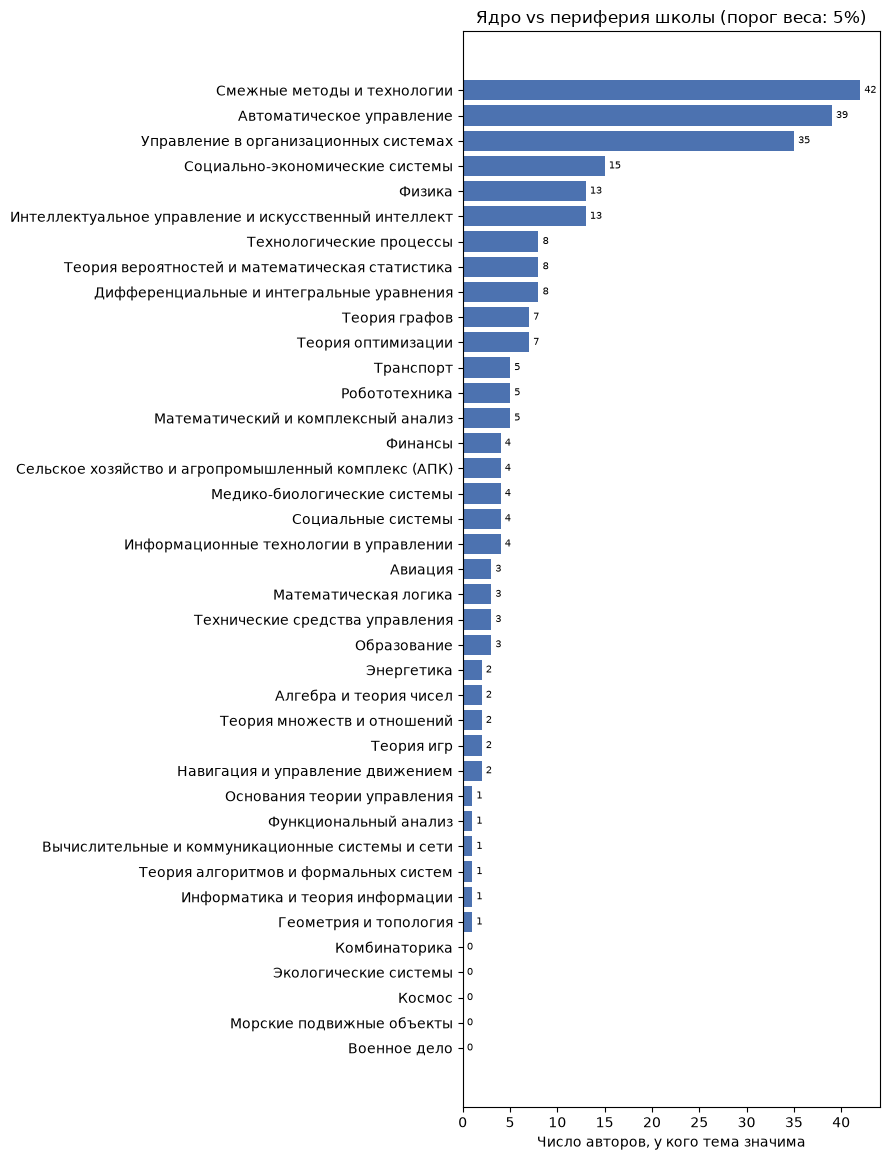

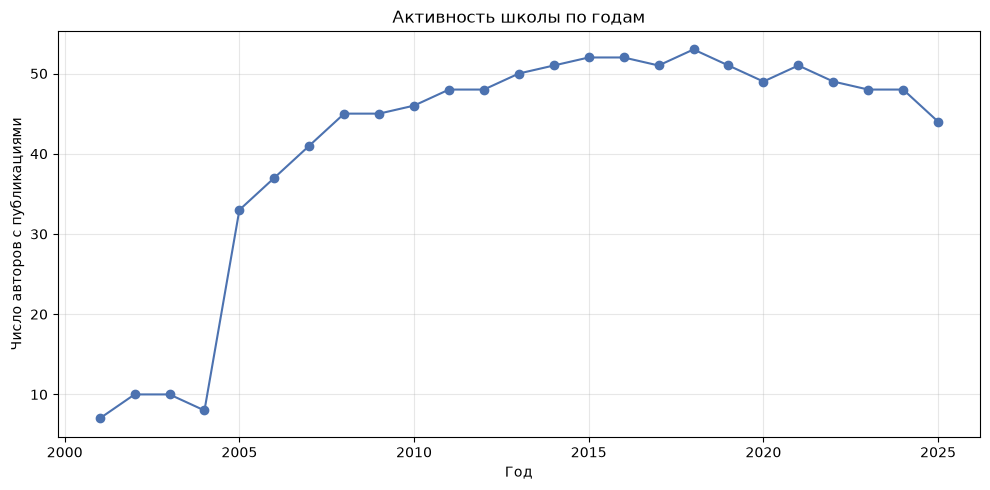

In [ ]:
school_by_year = school_vectors_all_years(data_vectors, factors_by_level, top_n=3)

n_topics = len(factors_by_level[str(sid)[1]])
options = list(range(1, n_topics + 1))

@interact_manual(count=Dropdown(options=options, description="Кол-во в топе тем:"))
def _(count):
    plot_school_topic_dynamics(school_by_year, factors_by_level, top_n=count)

@interact_manual(count=Dropdown(options=options, description="Кол-во в топе тем:"))
def _(count):
    trends = compute_topic_trends(school_by_year, factors_by_level)
    sorted_trends = print_topic_trends(trends, factors_by_level, top_n=count)
    plot_topic_trends(trends, factors_by_level, top_n=count)

threshold = 0.05  # 5%
level = str(sid)[1]
topic_reach = compute_topic_reach(data_overall, factors_by_level, threshold=threshold)
plot_topic_reach(topic_reach, factors_by_level, threshold=threshold)

plot_school_activity(school_by_year)

* 3.4. Предсказание будущего школы.

In [20]:
def plot_topic_forecast(school_by_year, trends, topic_id, factors_by_level, forecast_years=5):
    level = str(sid)[1]
    factors_map = factors_by_level[level]
    topic_name = factors_map.get(topic_id, topic_id)
    
    years = sorted(school_by_year.keys())
    values = [school_by_year[year]["vector"].get(topic_id, 0) * 100 for year in years]
    
    trend_data = trends[topic_id]
    slope = trend_data["slope"] * 100  # переводим в п.п./год
    intercept = trend_data["intercept"] * 100
    p_value = trend_data["p_value"]
    
    last_year = years[-1]
    future_years = list(range(last_year, last_year + forecast_years + 1))
    forecast_values = [slope * year + intercept for year in future_years]
    
    # защита от физически бессмысленного отрицательного процента
    forecast_values = [max(0, v) for v in forecast_values]
    
    plt.figure(figsize=(10, 6))
    plt.plot(years, values, marker='o', color="#4C72B0", label="Реальные данные")
    plt.plot(future_years, forecast_values, linestyle="--", marker='o', color="#B22222", label="Экстраполяция тренда")
    
    plt.axvline(last_year, color="gray", linestyle=":", alpha=0.5)
    plt.xlabel("Год")
    plt.ylabel("Доля, %")
    significance = "статистически значим" if p_value < 0.05 else "НЕ значим (осторожно!)"
    plt.title(f"{topic_name}\nТренд {significance} (p={p_value:.3f})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
trends = compute_topic_trends(school_by_year, factors_by_level)

level = str(sid)[1]
topic_options = {name: tid for tid, name in factors_by_level[level].items()}

@interact_manual(topic=Dropdown(options=topic_options, description="Тема:"), 
                  forecast_years=Dropdown(options=list(range(1, 11)), description="Лет вперёд:"))
def _(topic, forecast_years):
    plot_topic_forecast(school_by_year, trends, topic, factors_by_level, forecast_years=forecast_years)

interactive(children=(Dropdown(description='Тема:', options={'Алгебра и теория чисел': '7', 'Геометрия и топол…